In [56]:
# Cell 2: Импорты, seed и среда
import os
import random
import numpy as np
import pandas as pd
import torch
from datasets import load_dataset
from transformers import (
    AutoTokenizer, 
    AutoModelForSequenceClassification,
    pipeline
)
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Зафиксировать seed для воспроизводимости
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.backends.cudnn.deterministic = True

set_seed(42)

# Определить устройство
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используемое устройство: {device}")

Используемое устройство: cpu


In [57]:
# Cell 3: Данные и первичный анализ
dataset_name = "emotion"  # Используем рекомендованный датасет
dataset = load_dataset(dataset_name)

print("Структура датасета:")
for split in dataset.keys():
    print(f"{split}: {len(dataset[split])} примеров")

# Просмотр информации о классах
labels = dataset['train'].features['label']
print(f"\nКлассы: {labels.names}")
print(f"Число классов: {len(labels.names)}")

# Примеры данных
print("\nПримеры текстов и меток:")
for i in range(3):
    example = dataset['train'][i]
    print(f"Текст: {example['text'][:100]}...")
    print(f"Метка: {labels.int2str(example['label'])}")
    print("-" * 50)

Структура датасета:
train: 16000 примеров
validation: 2000 примеров
test: 2000 примеров

Классы: ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']
Число классов: 6

Примеры текстов и меток:
Текст: i didnt feel humiliated...
Метка: sadness
--------------------------------------------------
Текст: i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and ...
Метка: sadness
--------------------------------------------------
Текст: im grabbing a minute to post i feel greedy wrong...
Метка: anger
--------------------------------------------------


In [58]:
# Cell 4: Разделение данных
# Проверим, есть ли уже validation split
if 'validation' not in dataset:
    print("Validation split отсутствует, создаем из train...")
    # Разделим train на train и validation
    train_val = dataset['train'].train_test_split(test_size=0.2, seed=42)
    dataset['train'] = train_val['train']
    dataset['validation'] = train_val['test']

print("\nФинальное разделение:")
for split in ['train', 'validation', 'test']:
    if split in dataset:
        print(f"{split}: {len(dataset[split])} примеров")


Финальное разделение:
train: 16000 примеров
validation: 2000 примеров
test: 2000 примеров


In [59]:
# Cell 5: Токенизация
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_function(examples):
    # Токенизируем текст
    tokenized = tokenizer(
        examples['text'], 
        truncation=True, 
        padding=True, 
        max_length=128
    )
    # Сохраняем оригинальные метки (они уже в формате int индексов)
    tokenized['labels'] = examples['label']
    return tokenized

# Токенизация всех частей датасета
tokenized_datasets = {}
for split in ['train', 'validation', 'test']:
    if split in dataset:
        tokenized_datasets[split] = dataset[split].map(tokenize_function, batched=True)

print("\nПример токенизации:")
sample_text = dataset['train'][0]['text']
sample_tokens = tokenizer(sample_text, truncation=True, padding=True, max_length=128)
print(f"Оригинальный текст: {sample_text[:100]}...")
print(f"Токены: {tokenizer.convert_ids_to_tokens(sample_tokens['input_ids'])[:10]}...")
print(f"Input IDs: {sample_tokens['input_ids'][:10]}...")
print(f"Attention mask: {sample_tokens['attention_mask'][:10]}...")

# Демонстрация токенизации для нескольких примеров
print("\nДемонстрация токенизации для нескольких примеров:")
texts = [
    "I am so happy today!",
    "This makes me really angry.",
    "I feel very sad right now."
]

for text in texts:
    encoded = tokenizer(text, truncation=True, padding=True, max_length=128)
    tokens = tokenizer.convert_ids_to_tokens(encoded['input_ids'])
    
    print(f"\nТекст: '{text}'")
    print(f"Токены: {tokens}")
    print(f"Input IDs: {encoded['input_ids']}")
    print(f"Attention mask: {encoded['attention_mask']}")


Пример токенизации:
Оригинальный текст: i didnt feel humiliated...
Токены: ['[CLS]', 'i', 'didn', '##t', 'feel', 'humiliated', '[SEP]']...
Input IDs: [101, 1045, 2134, 2102, 2514, 26608, 102]...
Attention mask: [1, 1, 1, 1, 1, 1, 1]...

Демонстрация токенизации для нескольких примеров:

Текст: 'I am so happy today!'
Токены: ['[CLS]', 'i', 'am', 'so', 'happy', 'today', '!', '[SEP]']
Input IDs: [101, 1045, 2572, 2061, 3407, 2651, 999, 102]
Attention mask: [1, 1, 1, 1, 1, 1, 1, 1]

Текст: 'This makes me really angry.'
Токены: ['[CLS]', 'this', 'makes', 'me', 'really', 'angry', '.', '[SEP]']
Input IDs: [101, 2023, 3084, 2033, 2428, 4854, 1012, 102]
Attention mask: [1, 1, 1, 1, 1, 1, 1, 1]

Текст: 'I feel very sad right now.'
Токены: ['[CLS]', 'i', 'feel', 'very', 'sad', 'right', 'now', '.', '[SEP]']
Input IDs: [101, 1045, 2514, 2200, 6517, 2157, 2085, 1012, 102]
Attention mask: [1, 1, 1, 1, 1, 1, 1, 1, 1]


In [60]:
# Cell 6: Инференс готовой модели
print("\n=== Инференс готовой модели ===")

# Загрузка предобученной модели
pretrained_model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=len(labels.names)
)

# Создание pipeline для инференса
classifier = pipeline(
    "text-classification",
    model=pretrained_model,
    tokenizer=tokenizer,
    device=0 if torch.cuda.is_available() else -1,
    return_all_scores=True  # Чтобы видеть все вероятности
)

test_texts = [
    "I am extremely happy about this!",
    "This situation makes me furious.",
    "I feel quite sad today.",
    "What a wonderful surprise!",
    "I am terrified of what might happen."
]

print("Результаты инференса готовой (необученной) модели:")
for text in test_texts:
    result = classifier(text)[0]  # Берем первый (наиболее вероятный) результат
    print(f"Текст: '{text}' -> Предсказание: {result['label']}, Уверенность: {result['score']:.4f}")

print("\nКомментарий: Готовая модель не обучена на задаче классификации эмоций,")
print("поэтому результаты могут быть не очень точными.")


=== Инференс готовой модели ===


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 7160.94it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Результаты инференса готовой (необученной) модели:
Текст: 'I am extremely happy about this!' -> Предсказание: LABEL_3, Уверенность: 0.1816
Текст: 'This situation makes me furious.' -> Предсказание: LABEL_3, Уверенность: 0.1815
Текст: 'I feel quite sad today.' -> Предсказание: LABEL_3, Уверенность: 0.1818
Текст: 'What a wonderful surprise!' -> Предсказание: LABEL_3, Уверенность: 0.1803
Текст: 'I am terrified of what might happen.' -> Предсказание: LABEL_3, Уверенность: 0.1826

Комментарий: Готовая модель не обучена на задаче классификации эмоций,
поэтому результаты могут быть не очень точными.


In [61]:
# Cell 7: Fine-tuning для классификации текста
print("\n=== Fine-tuning модели ===")

# Загрузка модели для fine-tuning
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=len(labels.names)
)
model.to(device)

# Используем упрощенную реализацию обучения, чтобы избежать проблем с Trainer
from torch.utils.data import DataLoader
from torch.optim import AdamW
from tqdm.auto import tqdm

# Подготовка данных для обучения
train_dataset = tokenized_datasets['train']
val_dataset = tokenized_datasets['validation']

# Функция для создания батчей
def create_batch(items):
    """Функция для создания батча из списка элементов"""
    max_len = max(len(item['input_ids']) for item in items)
    
    input_ids = torch.stack([
        torch.tensor(item['input_ids'] + [tokenizer.pad_token_id] * (max_len - len(item['input_ids'])))
        for item in items
    ])
    
    attention_mask = torch.stack([
        torch.tensor(item['attention_mask'] + [0] * (max_len - len(item['attention_mask'])))
        for item in items
    ])
    
    labels_tensor = torch.tensor([item['labels'] for item in items], dtype=torch.long)
    
    return {
        'input_ids': input_ids,
        'attention_mask': attention_mask,
        'labels': labels_tensor
    }

# Оптимизатор
optimizer = AdamW(model.parameters(), lr=2e-5)

# Обучение модели (уменьшим количество эпох для скорости)
num_epochs = 1  # Уменьшено для скорости
batch_size = 8  # Уменьшено, чтобы избежать проблем с памятью

model.train()
for epoch in range(num_epochs):
    print(f"Epoch {epoch + 1}/{num_epochs}")
    
    # Проходим по тренировочным данным
    total_loss = 0
    num_batches = 0
    
    # Создаем временный список для батчинга
    current_batch = []
    
    for item in tqdm(train_dataset, desc="Training"):
        current_batch.append(item)
        
        if len(current_batch) == batch_size:
            # Создаем батч
            batch = create_batch(current_batch)
            
            # Перемещаем на устройство
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels_tensor = batch['labels'].to(device)
            
            # Прямой проход
            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels_tensor)
            loss = outputs.loss
            
            # Обратный проход
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
            num_batches += 1
            
            # Очищаем батч
            current_batch = []
    
    # Обрабатываем оставшиеся элементы, если они есть
    if current_batch:
        batch = create_batch(current_batch)
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels_tensor = batch['labels'].to(device)
        
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels_tensor)
        loss = outputs.loss
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        num_batches += 1
    
    avg_loss = total_loss / num_batches
    print(f"Average training loss: {avg_loss:.4f}")


=== Fine-tuning модели ===


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 4504.58it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1/1


Training: 100%|██████████| 16000/16000 [33:35<00:00,  7.94it/s] 

Average training loss: 0.3927


In [62]:
# Cell 8: Оценка на validation
print("\n=== Оценка на validation ===")

model.eval()
val_predictions = []
val_true_labels = []

current_batch = []
batch_size = 8

for item in tqdm(val_dataset, desc="Validating"):
    current_batch.append(item)
    
    if len(current_batch) == batch_size:
        batch = create_batch(current_batch)
        
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels_tensor = batch['labels'].to(device)
        
        with torch.no_grad():
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            predictions = torch.argmax(outputs.logits, dim=-1)
        
        val_predictions.extend(predictions.cpu().numpy())
        val_true_labels.extend(labels_tensor.cpu().numpy())
        
        current_batch = []

# Обрабатываем оставшиеся элементы
if current_batch:
    batch = create_batch(current_batch)
    input_ids = batch['input_ids'].to(device)
    attention_mask = batch['attention_mask'].to(device)
    labels_tensor = batch['labels'].to(device)
    
    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        predictions = torch.argmax(outputs.logits, dim=-1)
    
    val_predictions.extend(predictions.cpu().numpy())
    val_true_labels.extend(labels_tensor.cpu().numpy())

# Вычисление метрик на validation
val_accuracy = accuracy_score(val_true_labels, val_predictions)
val_f1_macro = f1_score(val_true_labels, val_predictions, average='macro')

print(f"Validation Accuracy: {val_accuracy:.4f}")
print(f"Validation F1-macro: {val_f1_macro:.4f}")


=== Оценка на validation ===


Validating: 100%|██████████| 2000/2000 [00:45<00:00, 43.62it/s]

Validation Accuracy: 0.9350
Validation F1-macro: 0.9038


In [63]:
# Cell 9: Оценка лучшей модели на test
print("\n=== Финальная оценка на test ===")

test_dataset = tokenized_datasets['test']

model.eval()
test_predictions = []
test_true_labels = []

current_batch = []
batch_size = 8

for item in tqdm(test_dataset, desc="Testing"):
    current_batch.append(item)
    
    if len(current_batch) == batch_size:
        batch = create_batch(current_batch)
        
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels_tensor = batch['labels'].to(device)
        
        with torch.no_grad():
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            predictions = torch.argmax(outputs.logits, dim=-1)
        
        test_predictions.extend(predictions.cpu().numpy())
        test_true_labels.extend(labels_tensor.cpu().numpy())
        
        current_batch = []

# Обрабатываем оставшиеся элементы
if current_batch:
    batch = create_batch(current_batch)
    input_ids = batch['input_ids'].to(device)
    attention_mask = batch['attention_mask'].to(device)
    labels_tensor = batch['labels'].to(device)
    
    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        predictions = torch.argmax(outputs.logits, dim=-1)
    
    test_predictions.extend(predictions.cpu().numpy())
    test_true_labels.extend(labels_tensor.cpu().numpy())

# Вычисление метрик на тесте
test_accuracy = accuracy_score(test_true_labels, test_predictions)
test_f1_macro = f1_score(test_true_labels, test_predictions, average='macro')

print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test F1-macro: {test_f1_macro:.4f}")


=== Финальная оценка на test ===


Testing: 100%|██████████| 2000/2000 [00:45<00:00, 43.77it/s]

Test Accuracy: 0.9280
Test F1-macro: 0.8880



=== Оценка качества ===


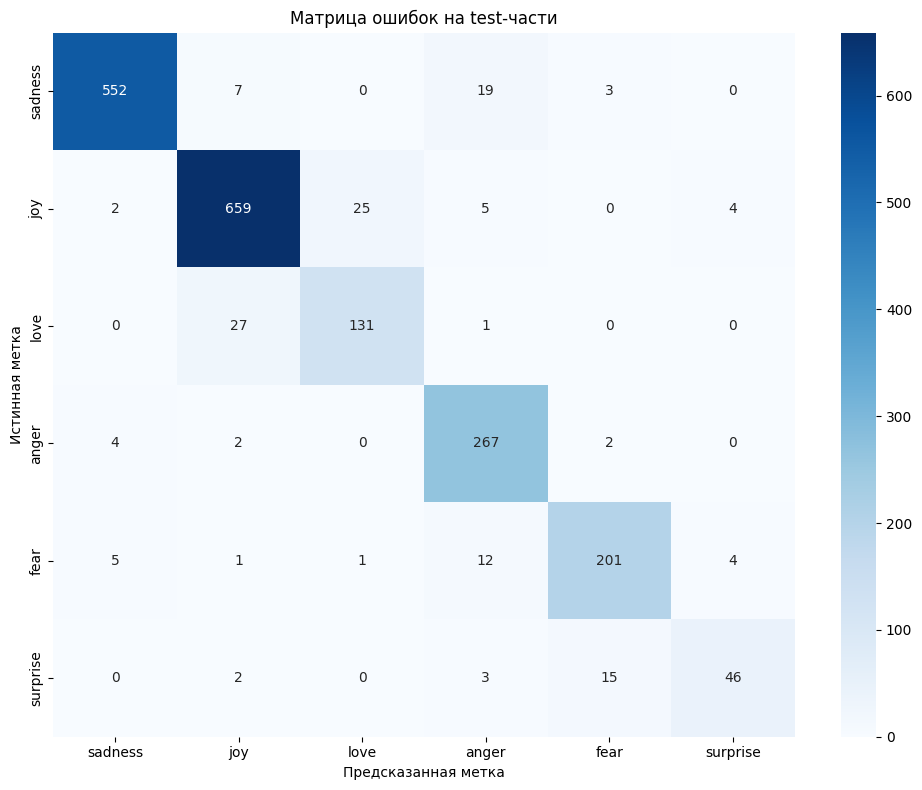

Матрица ошибок сохранена в artifacts/confusion_matrix.png


In [64]:
# Cell 10: Оценка качества и краткий анализ ошибок
print("\n=== Оценка качества ===")

# Построение матрицы ошибок
cm = confusion_matrix(test_true_labels, test_predictions)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues',
    xticklabels=labels.names,
    yticklabels=labels.names
)
plt.title('Матрица ошибок на test-части')
plt.xlabel('Предсказанная метка')
plt.ylabel('Истинная метка')
plt.tight_layout()
plt.savefig('artifacts/confusion_matrix.png')
plt.show()

print("Матрица ошибок сохранена в artifacts/confusion_matrix.png")

In [66]:
# Cell 11: Примеры предсказаний
print("\n=== Примеры предсказаний ===")

# Создание DataFrame с примерами предсказаний
sample_predictions = []
num_samples = min(10, len(test_dataset))

for i in range(num_samples):
    text = dataset['test'][i]['text']
    true_label = labels.int2str(dataset['test'][i]['label'])
    # Преобразуем предсказание в Python int перед передачей в int2str
    pred_label = labels.int2str(int(test_predictions[i]))
    
    # Получение уверенности
    item = test_dataset[i]
    input_ids = torch.tensor([item['input_ids']]).to(device)
    attention_mask = torch.tensor([item['attention_mask']]).to(device)
    
    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits[0]
        probs = torch.softmax(logits, dim=0)
        confidence = float(probs.max())
    
    sample_predictions.append({
        'text': text,
        'true_label': true_label,
        'pred_label': pred_label,
        'confidence': confidence
    })

predictions_df = pd.DataFrame(sample_predictions)
predictions_df.to_csv('artifacts/sample_predictions.csv', index=False)

print("Примеры предсказаний:")
print(predictions_df[['text', 'true_label', 'pred_label', 'confidence']])
print("\nФайл sample_predictions.csv сохранен в artifacts/")


=== Примеры предсказаний ===
Примеры предсказаний:
                                                text true_label pred_label  \
0  im feeling rather rotten so im not very ambiti...    sadness    sadness   
1          im updating my blog because i feel shitty    sadness    sadness   
2  i never make her separate from me because i do...    sadness    sadness   
3  i left with my bouquet of red and yellow tulip...        joy        joy   
4    i was feeling a little vain when i did this one    sadness    sadness   
5  i cant walk into a shop anywhere where i do no...       fear       fear   
6   i felt anger when at the end of a telephone call      anger      anger   
7  i explain why i clung to a relationship with a...        joy        joy   
8  i like to have the same breathless feeling as ...        joy        joy   
9  i jest i feel grumpy tired and pre menstrual w...      anger      anger   

   confidence  
0    0.990048  
1    0.994359  
2    0.995268  
3    0.996706  
4    0.99

In [67]:
# Cell 12: Краткий анализ ошибок
print("\n=== Краткий анализ ошибок ===")

# Найдем индексы, где предсказание не совпало с истиной
error_indices = [i for i, (true, pred) in enumerate(zip(test_true_labels, test_predictions)) if true != pred]
print(f"Найдено {len(error_indices)} ошибочных предсказаний из {len(test_true_labels)}")

print("\nПримеры ошибок:")
for i, idx in enumerate(error_indices[:5]):  # Показываем первые 5 ошибок
    text = dataset['test'][idx]['text']
    # Преобразуем в Python int перед передачей в int2str
    true_label = labels.int2str(int(test_true_labels[idx]))
    pred_label = labels.int2str(int(test_predictions[idx]))
    
    print(f"\nПример {i+1}:")
    print(f"  Текст: {text[:150]}...")
    print(f"  Истинная метка: {true_label}")
    print(f"  Предсказанная метка: {pred_label}")


=== Краткий анализ ошибок ===
Найдено 144 ошибочных предсказаний из 2000

Примеры ошибок:

Пример 1:
  Текст: i don t feel particularly agitated...
  Истинная метка: fear
  Предсказанная метка: anger

Пример 2:
  Текст: i pay attention it deepens into a feeling of being invaded and helpless...
  Истинная метка: fear
  Предсказанная метка: anger

Пример 3:
  Текст: i am right handed however i play billiards left handed naturally so me trying to play right handed feels weird...
  Истинная метка: surprise
  Предсказанная метка: fear

Пример 4:
  Текст: i feel agitated with myself that i did not foresee her frustrations earlier leading to the ending of our relationship...
  Истинная метка: fear
  Предсказанная метка: anger

Пример 5:
  Текст: i feel is he generous...
  Истинная метка: love
  Предсказанная метка: joy


In [68]:
# Cell 13: Выводы
print("\n=== Выводы ===")
print(f"Accuracy на test: {test_accuracy:.4f}")
print(f"F1-macro на test: {test_f1_macro:.4f}")
print(f"Количество классов: {len(labels.names)}")
print(f"Количество параметров модели: {model.num_parameters():,}")


=== Выводы ===
Accuracy на test: 0.9280
F1-macro на test: 0.8880
Количество классов: 6
Количество параметров модели: 66,958,086
